# EM Fixed Income Analytics Suite

#### Programming choices:

Start date = 2015-01-01, capturing multiple EM stress situations

List of problems faced:

- Data Sourcing: WRDS didn't work, despite successfully conecting my account it does not have the necessary info, had to manually download
- File names in Investing.com sometimes had typos -> quick fix by renaming, this even bypassed the column check
- 2Y Colombia resulted in 65.35% data loss, 20Y Hungary resulted in 43.42% data loss, both were removed. Next largest offender was 1Y romania but it wasn't due to a lack of reporting before a certain period (patchy), so it was kept


Things I want to better understand before turning the project in:
- PCA analysis, finish watching 3Blue1Brown videos to better understand the process despite having the basics nailed down
- Why was 1Y just noise for Romania

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import json
from pathlib import Path
from collections import defaultdict
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import missingno as msno
from matplotlib_inline import config
from sklearn.mixture import GaussianMixture
from scipy.stats import norm, t as t_dist
from scipy.stats import chi2
from google import genai
import time



In [2]:
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})
 
MACRO_EVENTS = {
    "2015-08-24": "CNY devaluation",
    "2016-11-09": "Trump election",
    "2018-05-01": "EM sell-off (Turkey/Argentina)",
    "2020-03-16": "Covid crash",
    "2021-03-17": "Fed dots hawkish shift",
    "2022-03-16": "Fed first hike (post-Covid)",
    "2022-09-26": "UK gilt crisis / EM contagion",
    "2023-10-19": "US 10Y hits 5%",
    "2024-09-18": "Fed pivot (first cut)",
    "2025-01-20": "Trump 2.0 inauguration",
}


## 1. Yield Curve PCA & Regime Detection

### 1.1 Downloading Data

#### Country Selection

In [3]:
local_list_of_countries = ['Brazil','Mexico','South Africa','Poland']
hard_list_of_countries = ['Colombia', 'Hungary','Romania']
all_countries = sorted(set(local_list_of_countries + hard_list_of_countries))

#### Data Scraping

Getting all the data for countries via Investing.com
Maturities vary per country: maximizing coverage, avoiding redudancy between adjacent points when possible

As I don't have access to my Bloomberg while doing this project, I'll need to find another way to obtain Hard currency bond yields.
Proxy spreads: local-currency yields - US treasury yields

Source: https://www.investing.com/rates-bonds/

Jordan was removed from the hard currency list due to limited data availability from Investing.com

#### Cleaning the Data

In [4]:
base_dir = Path(r'data\raw')
all_unique_columns = set()
column_provenance = defaultdict(list)

for file_path in base_dir.rglob("*.csv"):
    try:
        raw_columns = pd.read_csv(file_path, nrows=0).columns.tolist()
        all_unique_columns.update(raw_columns)

        for col in raw_columns:
            column_provenance[col].append(file_path.name)
    except Exception as e:
        print(f"Failed to read header of {file_path.name}: {e}")

print(f"Total Unique Raw Columns Discovered: {len(all_unique_columns)}\n")
for col in sorted(all_unique_columns):
    file_count = len(column_provenance[col])
    print(f"'{col}' -> Found in {file_count} files")

Total Unique Raw Columns Discovered: 6

'Change %' -> Found in 32 files
'Date' -> Found in 32 files
'High' -> Found in 32 files
'Low' -> Found in 32 files
'Open' -> Found in 32 files
'Price' -> Found in 32 files


In [5]:
files = glob.glob("data/raw/*/*.csv")
print("Files found:", len(files))

country_files = defaultdict(list)
for f in files:
    match = re.search(r"(\w[\w\s]+?)\s+(\d+)-Year Bond", f)
    if match:
        country  = match.group(1)
        maturity = match.group(2) + "Y"
        country_files[country].append((maturity, f))
    else:
        print(f"NO MATCH: {f}")

country_dfs = {}
for country, maturity_files in country_files.items():
    dfs = []
    for maturity, fname in maturity_files:
        df = pd.read_csv(fname, usecols=["Date", "Price"])
        df["Date"] = pd.to_datetime(df["Date"])
        df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
        df = df.rename(columns={"Price": maturity})
        df = df.set_index("Date")
        dfs.append(df)
    
    combined = pd.concat(dfs, axis=1).sort_index().loc["2015-01-01":"2026-05-01"]
    combined = combined[sorted(combined.columns, key=lambda x: int(x[:-1]))]
    country_dfs[country] = combined

for country, df in country_dfs.items():
    print(f"{country}: {df.shape} | columns: {list(df.columns)}")

Files found: 32
Brazil: (3016, 5) | columns: ['2Y', '3Y', '5Y', '8Y', '10Y']
Colombia: (3403, 4) | columns: ['4Y', '5Y', '10Y', '15Y']
Hungary: (2962, 4) | columns: ['1Y', '5Y', '10Y', '15Y']
Mexico: (3260, 5) | columns: ['3Y', '5Y', '10Y', '20Y', '30Y']
Poland: (3457, 5) | columns: ['1Y', '2Y', '3Y', '5Y', '10Y']
Romania: (3446, 4) | columns: ['3Y', '5Y', '7Y', '10Y']
South Africa: (2891, 5) | columns: ['5Y', '10Y', '12Y', '20Y', '30Y']


In [6]:
for country, df in country_dfs.items():
    df.to_csv(f"data/output/{country}.csv")
    print(f"Saved {country}")

Saved Brazil
Saved Colombia
Saved Hungary
Saved Mexico
Saved Poland
Saved Romania
Saved South Africa


### 1.2 PCA on the Yield Curve

In [7]:
change_dfs = {}

for country, df in country_dfs.items():
    dy = df.diff().dropna()
    dy = dy.dropna()

    change_dfs[country] = dy
    pct_lost = 100 * (1 - len(dy) / len(df))
    print(f"For {country}: {len(dy)} observations left after calculating difference and dropping N/As ({pct_lost:.2f}% of data lost)")

For Brazil: 2698 observations left after calculating difference and dropping N/As (10.54% of data lost)
For Colombia: 2847 observations left after calculating difference and dropping N/As (16.34% of data lost)
For Hungary: 2748 observations left after calculating difference and dropping N/As (7.22% of data lost)
For Mexico: 2778 observations left after calculating difference and dropping N/As (14.79% of data lost)
For Poland: 2640 observations left after calculating difference and dropping N/As (23.63% of data lost)
For Romania: 2685 observations left after calculating difference and dropping N/As (22.08% of data lost)
For South Africa: 2089 observations left after calculating difference and dropping N/As (27.74% of data lost)


Inspecting missing data to make sure PCA runs properly: removed 2Y Colombia, 20Y Hungary

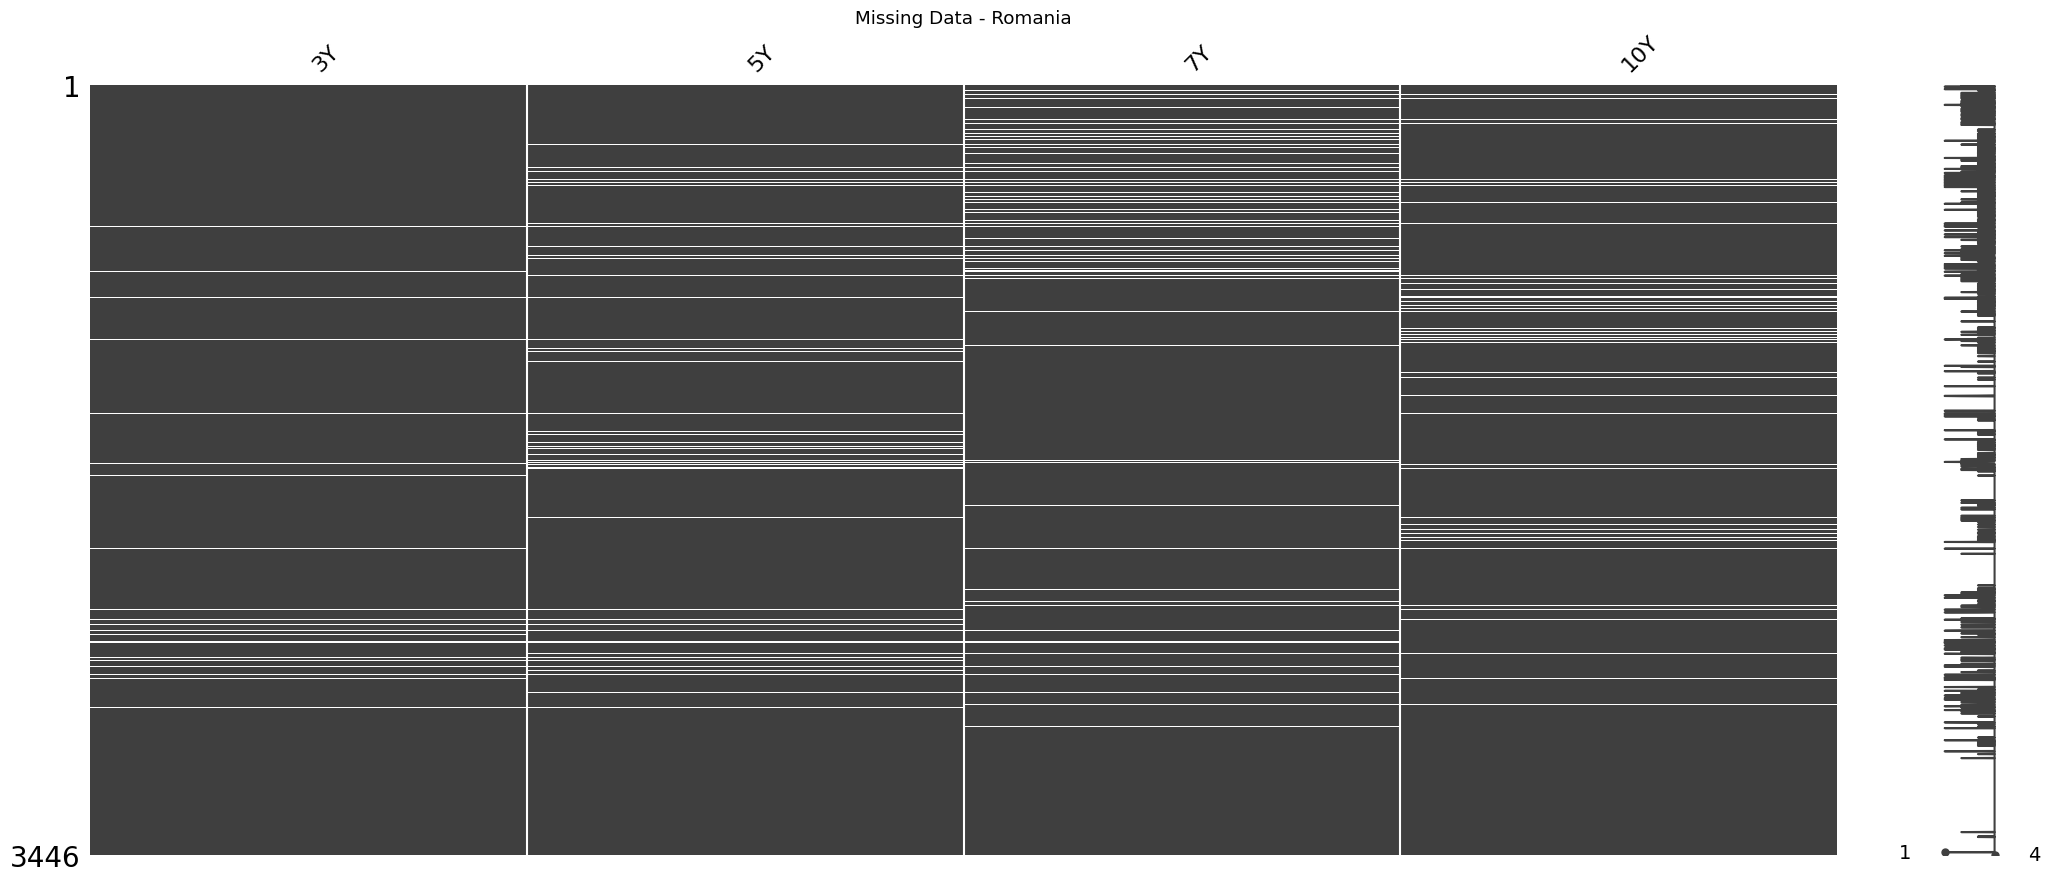

In [8]:
c = "Romania"
df = country_dfs[c]
msno.matrix(df)
plt.title(f"Missing Data - {c}")
plt.show()

In [9]:
pca_results = {}
for country, dy in change_dfs.items():
    scaler = StandardScaler()
    dy_std = scaler.fit_transform(dy)
 
    pca = PCA(n_components=3)
    scores = pca.fit_transform(dy_std)
 
    scores_df = pd.DataFrame(
        scores,
        index=dy.index,
        columns=["PC1 (level)", "PC2 (slope)", "PC3 (curvature)"],
    )
    loadings_df = pd.DataFrame(
        pca.components_.T,
        index=dy.columns,
        columns=["PC1", "PC2", "PC3"],
    )
 
    pca_results[country] = {
        "pca": pca,
        "scaler": scaler,
        "scores": scores_df,
        "loadings": loadings_df,
    }
 
    evr = pca.explained_variance_ratio_
    print(
        f"{country}: PC1={evr[0]:.1%}  PC2={evr[1]:.1%}  PC3={evr[2]:.1%}  "
        f"cumulative={evr.sum():.1%}"
    )


Brazil: PC1=76.3%  PC2=11.4%  PC3=6.1%  cumulative=93.7%
Colombia: PC1=53.1%  PC2=25.0%  PC3=15.7%  cumulative=93.8%
Hungary: PC1=51.8%  PC2=25.0%  PC3=21.9%  cumulative=98.8%
Mexico: PC1=56.4%  PC2=36.2%  PC3=3.7%  cumulative=96.3%
Poland: PC1=72.6%  PC2=14.0%  PC3=7.1%  cumulative=93.8%
Romania: PC1=68.4%  PC2=12.0%  PC3=10.8%  cumulative=91.1%
South Africa: PC1=89.9%  PC2=6.9%  PC3=2.1%  cumulative=99.0%


Removed Romania 1Y as it was introducing noise

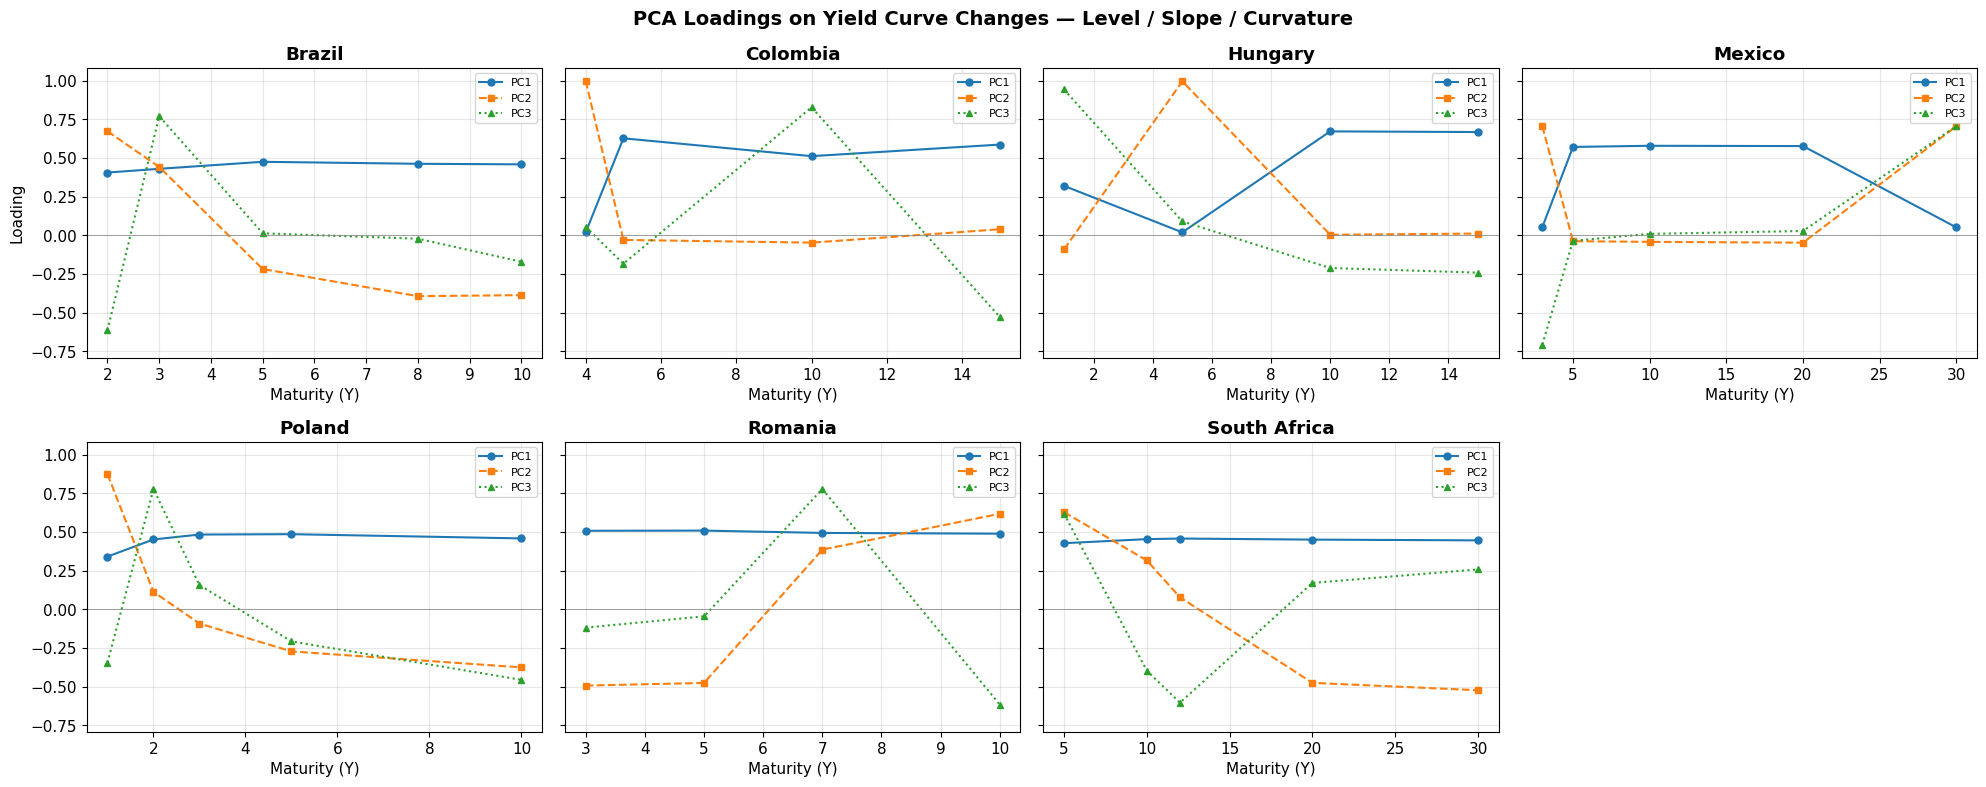

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=True)
axes = axes.flatten()
 
for i, (country, res) in enumerate(sorted(pca_results.items())):
    ax = axes[i]
    loadings = res["loadings"]
    maturities = [int(m[:-1]) for m in loadings.index]
 
    for pc_col, style in zip(loadings.columns, ["-o", "--s", ":^"]):
        ax.plot(maturities, loadings[pc_col], style, label=pc_col, markersize=5)
 
    ax.set_title(country, fontweight="bold")
    ax.set_xlabel("Maturity (Y)")
    ax.axhline(0, color="grey", linewidth=0.5)
    if i == 0:
        ax.set_ylabel("Loading")
    ax.legend(fontsize=8)
 
# Hide the 8th (empty) subplot
axes[-1].set_visible(False)
fig.suptitle(
    "PCA Loadings on Yield Curve Changes — Level / Slope / Curvature",
    fontsize=14,
    fontweight="bold",
)
fig.tight_layout()
plt.savefig("data/output/pca_loadings.png", dpi=150, bbox_inches="tight")
plt.show()


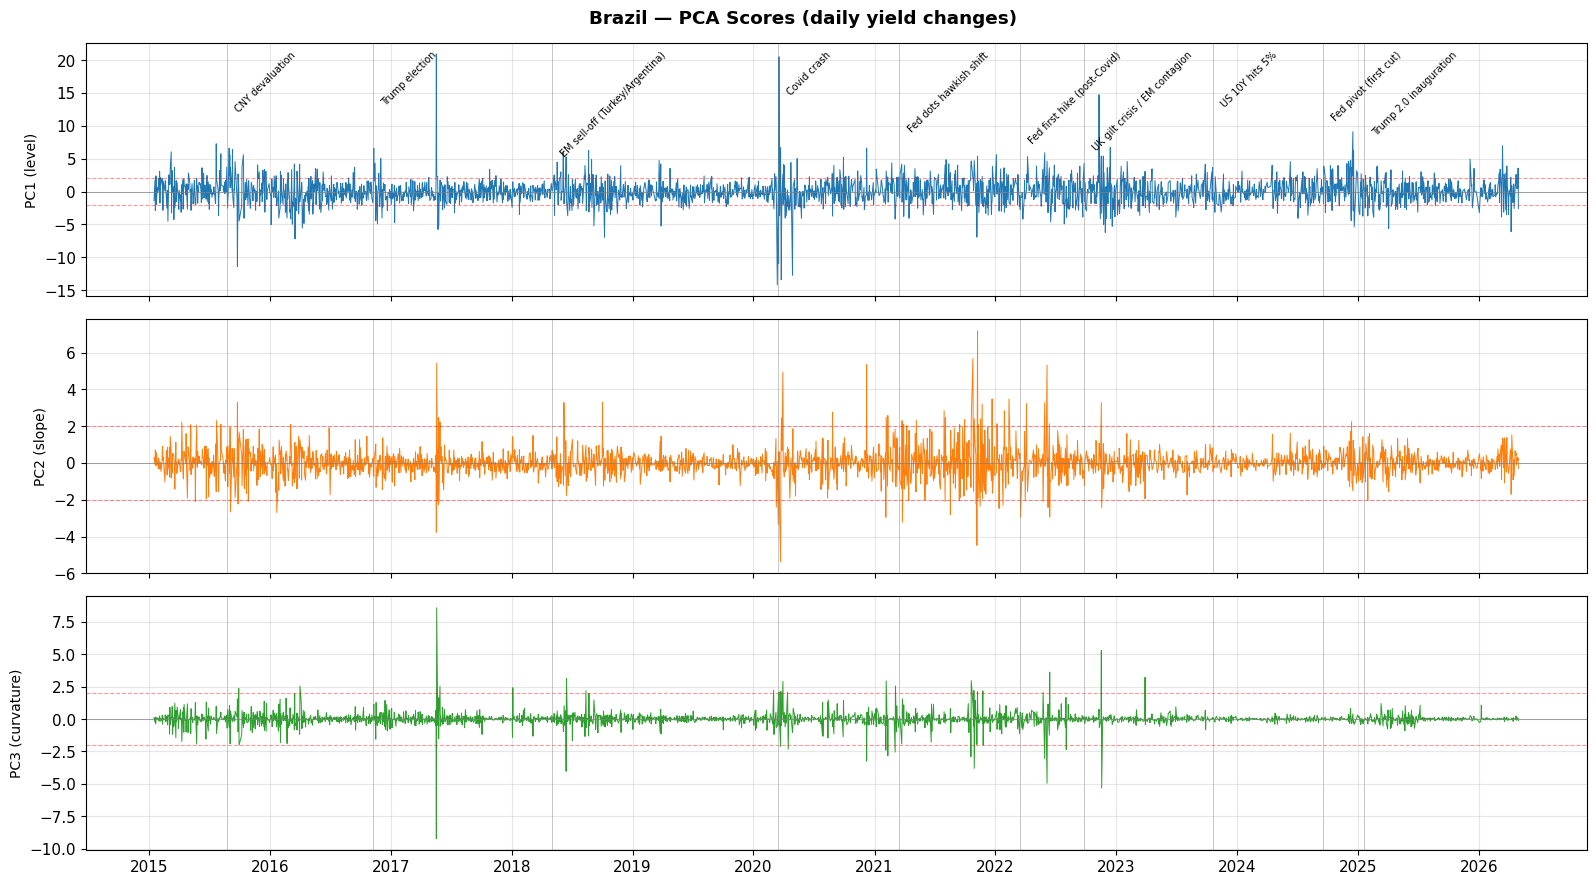

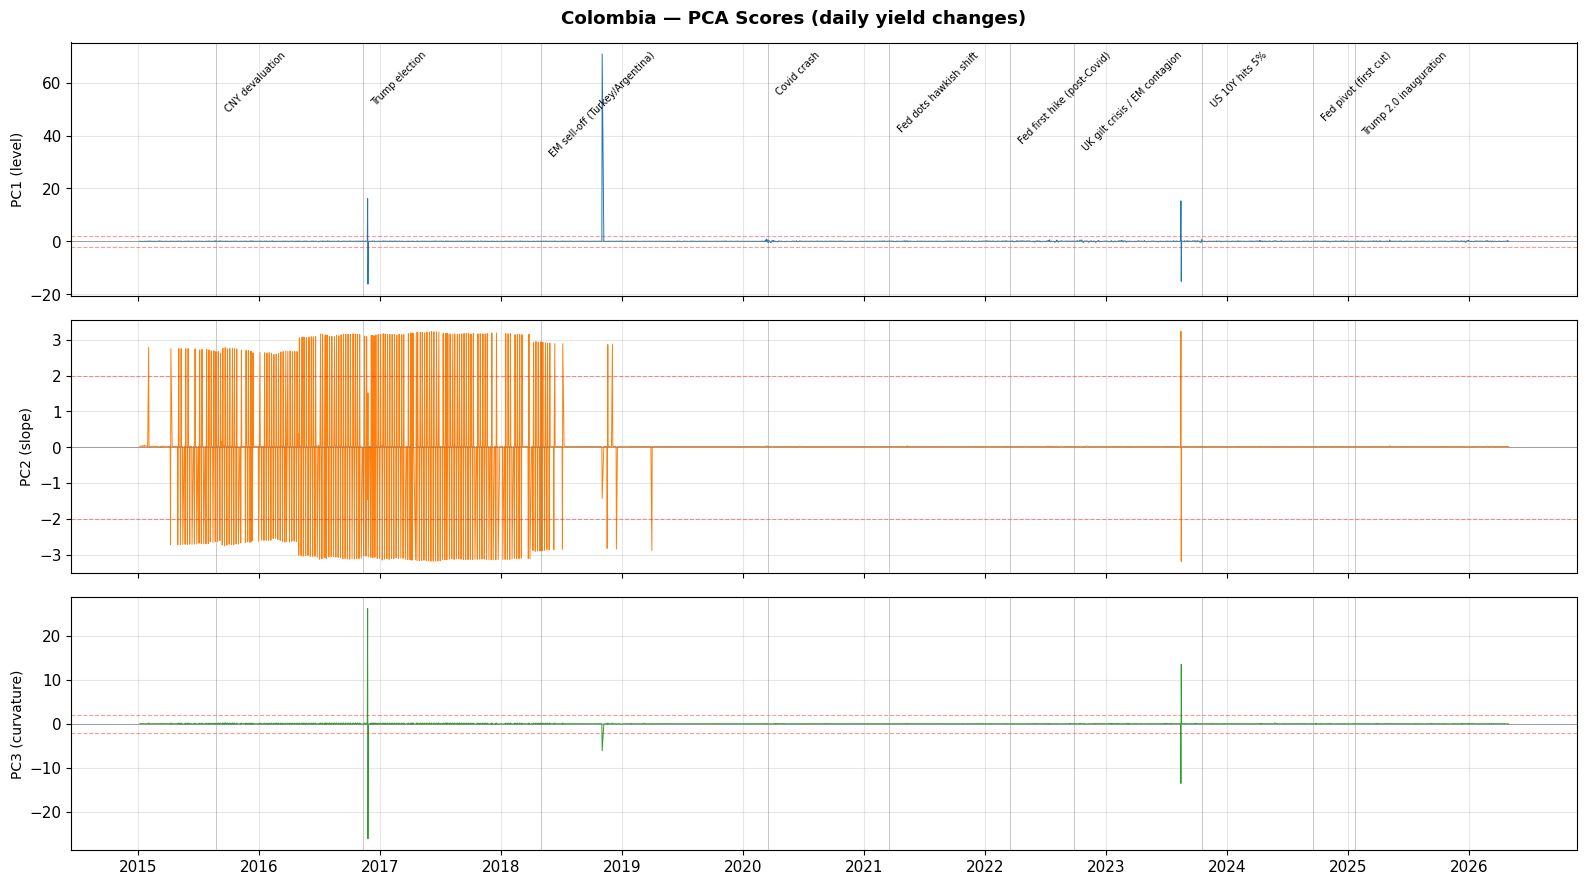

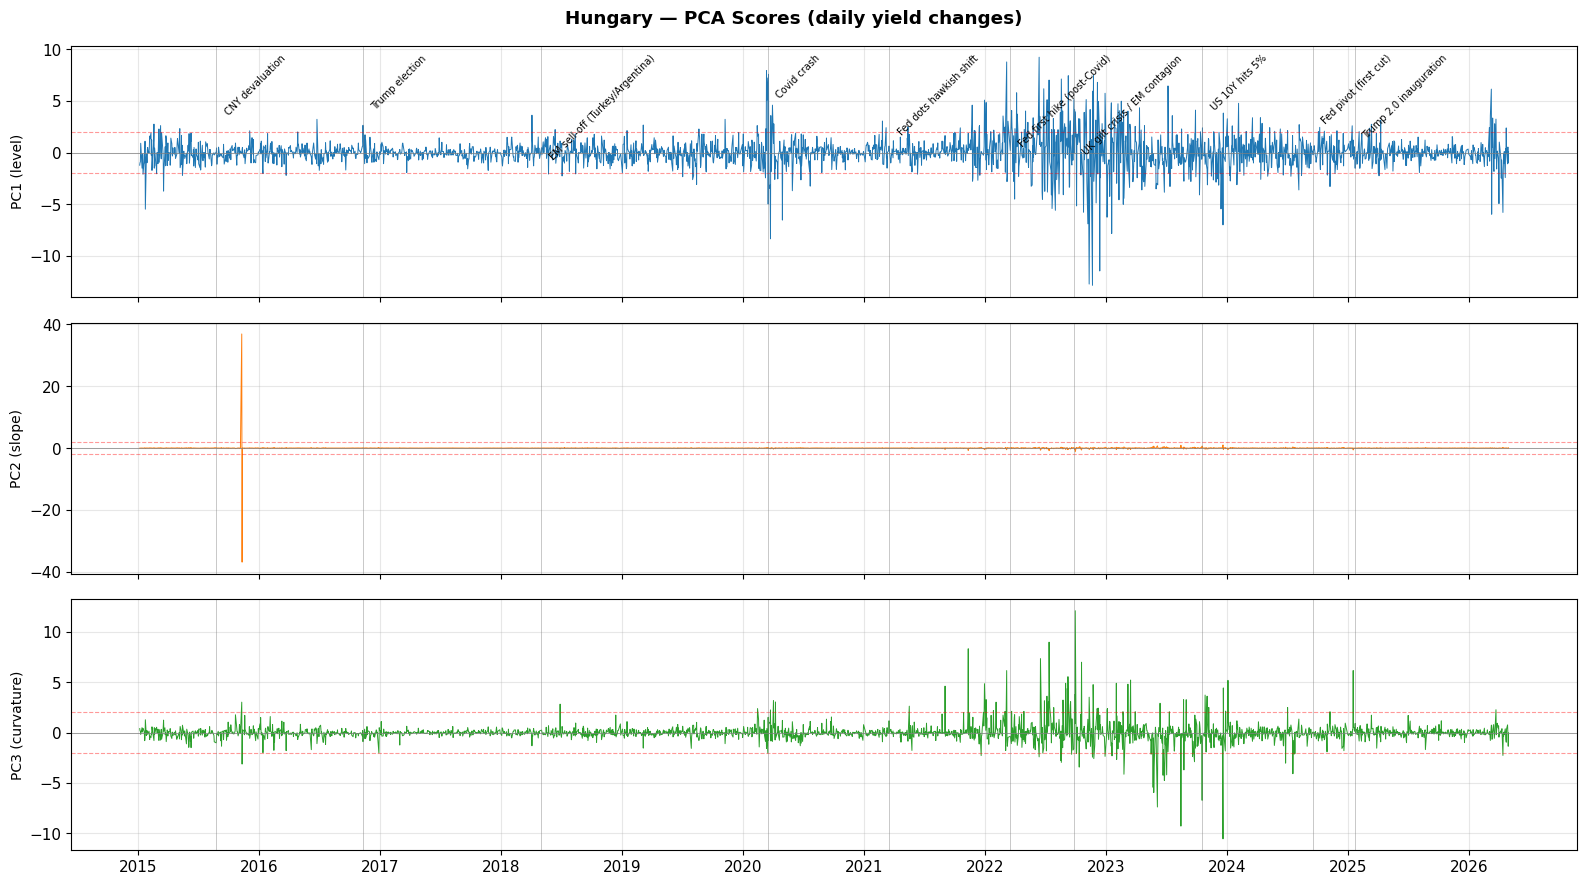

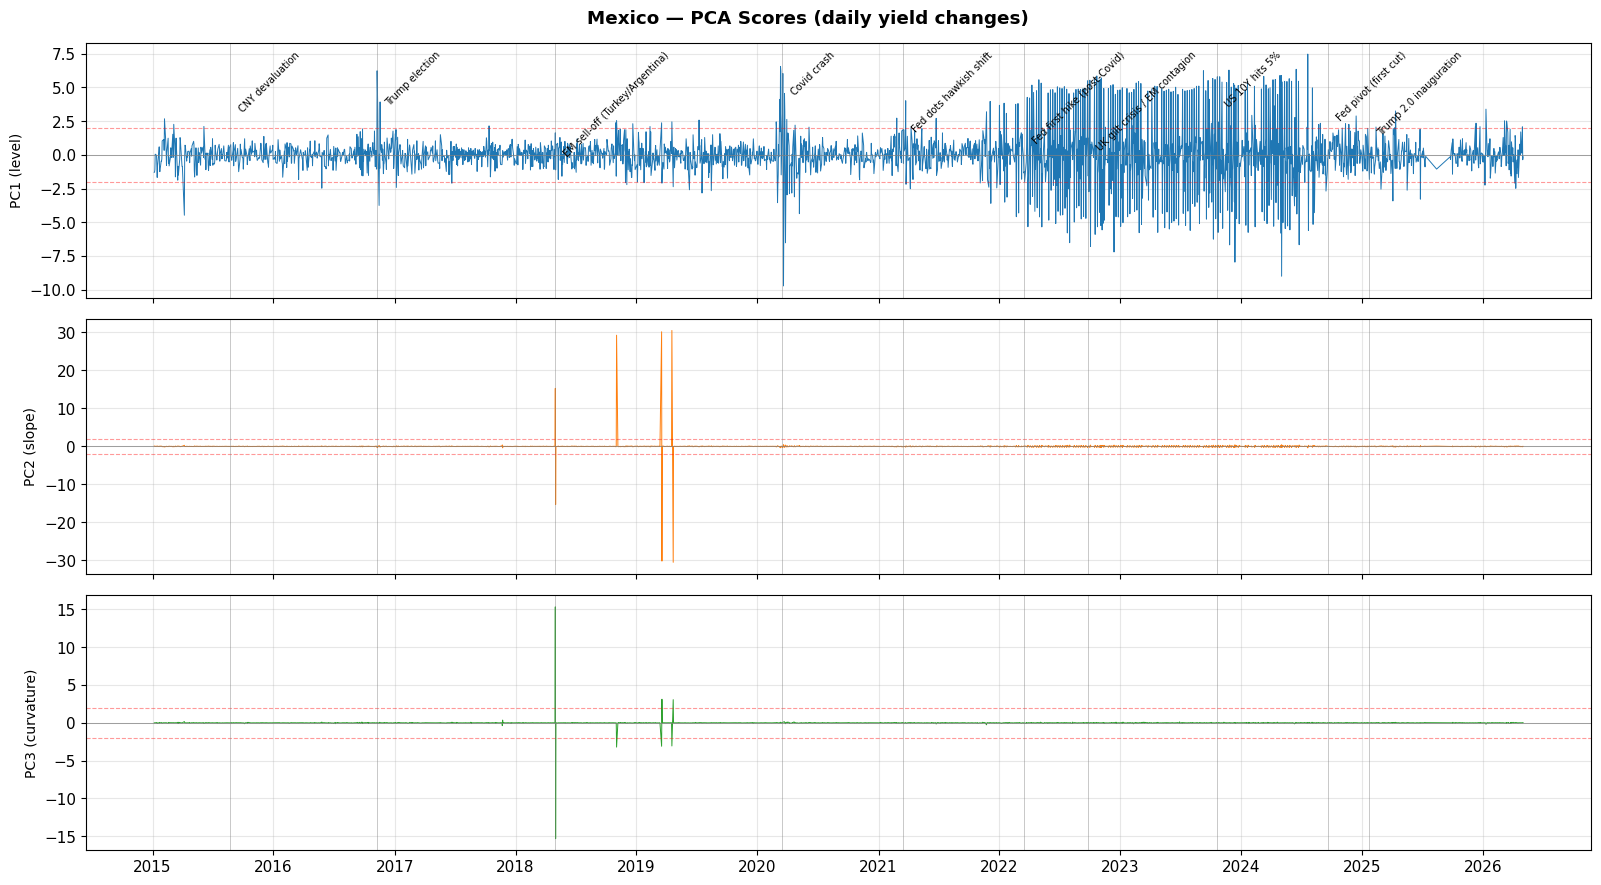

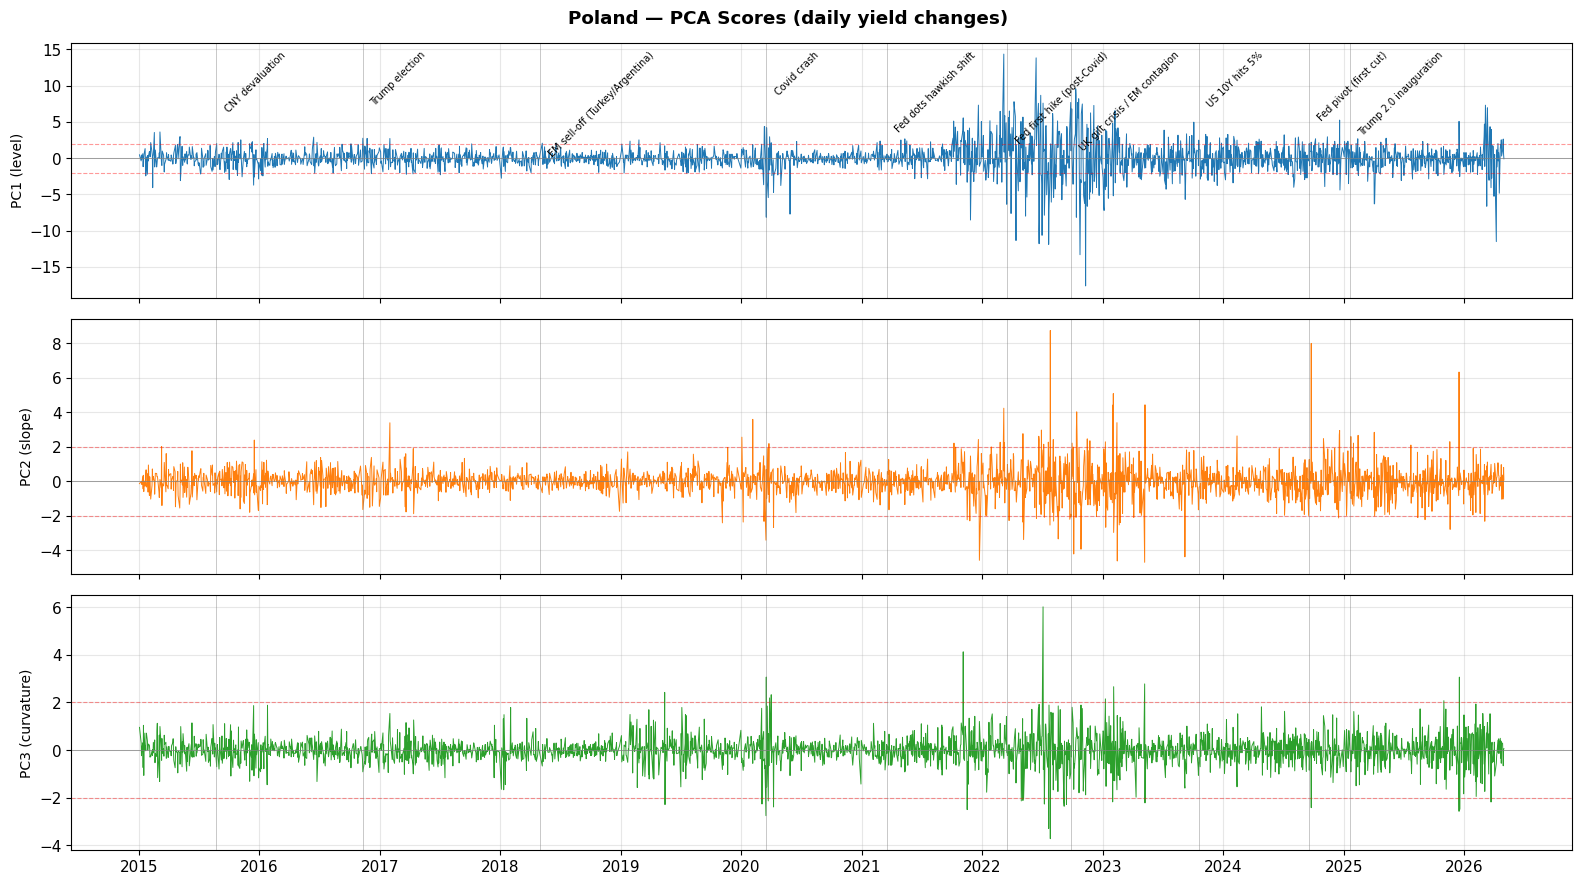

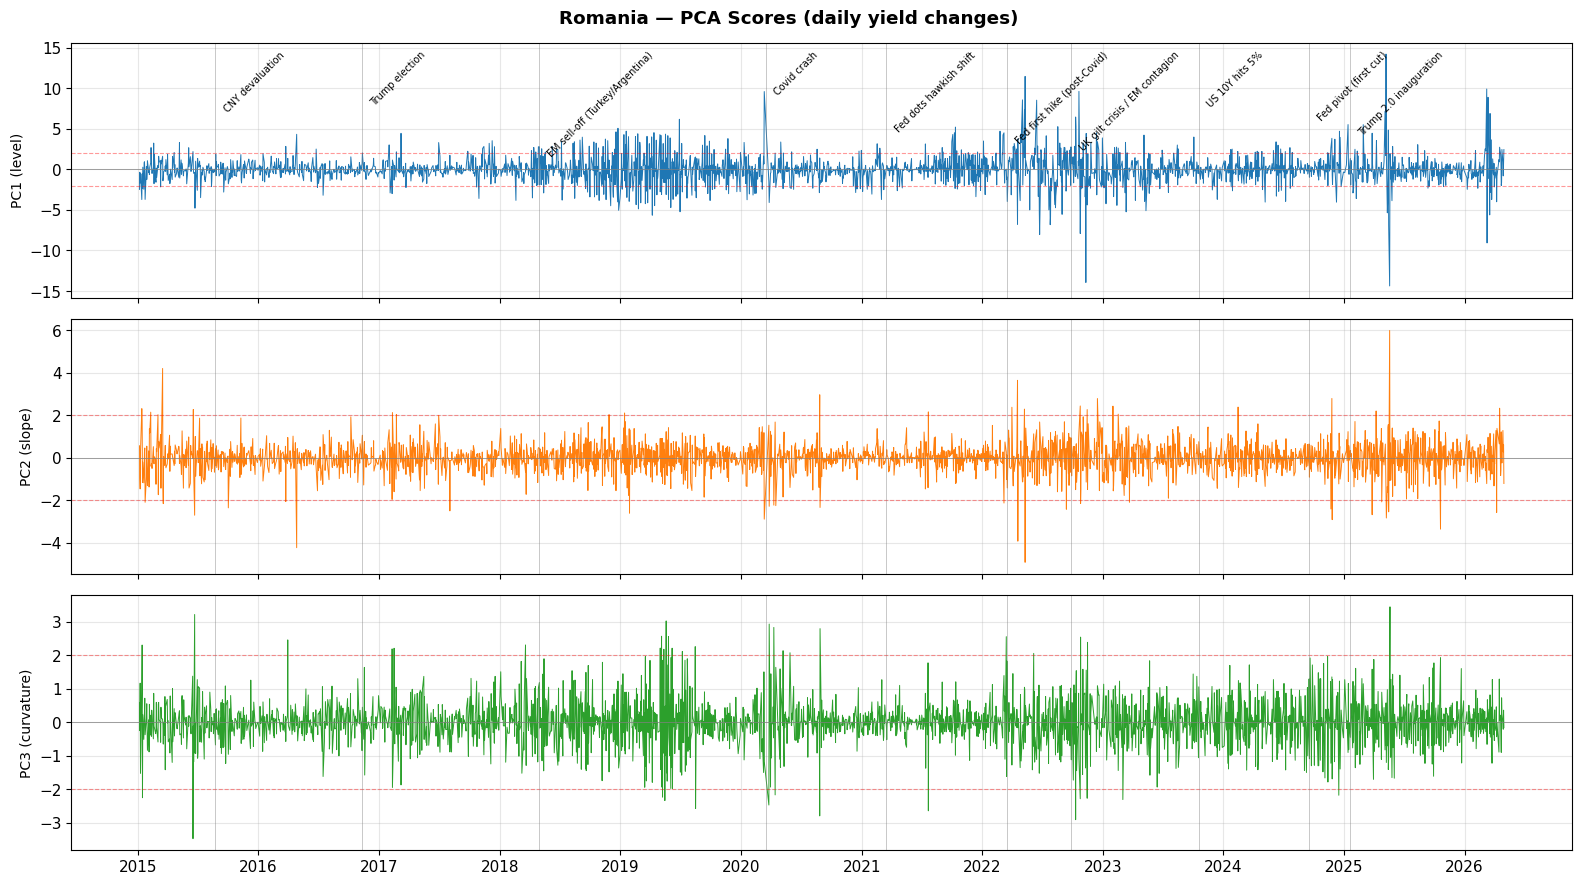

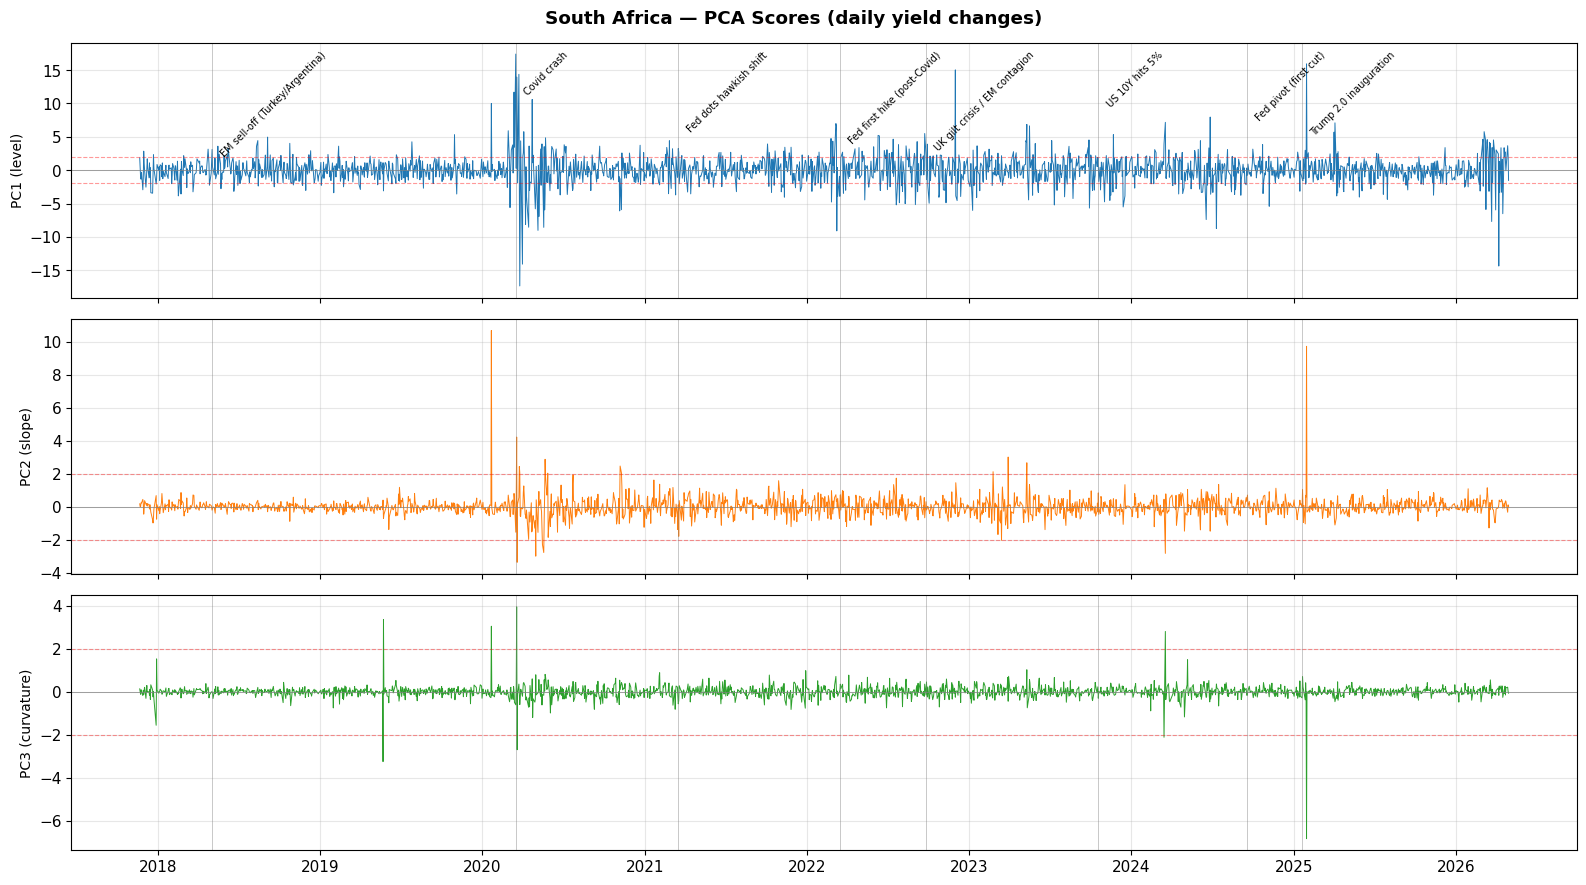

In [11]:
def plot_pc_scores(country, scores_df, macro_events):
    """Plot 3 PC score time series with macro event annotations."""
    fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
 
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
    for j, col in enumerate(scores_df.columns):
        ax = axes[j]
        ax.plot(scores_df.index, scores_df[col], linewidth=0.7, color=colors[j])
        ax.set_ylabel(col, fontsize=10)
        ax.axhline(0, color="grey", linewidth=0.5)
 
        # ±2σ bands (z-score alert threshold from blueprint §1.4)
        ax.axhline(2, color="red", linestyle="--", alpha=0.4, linewidth=0.8)
        ax.axhline(-2, color="red", linestyle="--", alpha=0.4, linewidth=0.8)
 
        # Macro event annotations
        for date_str, label in macro_events.items():
            evt_date = pd.Timestamp(date_str)
            if evt_date in scores_df.index or (
                scores_df.index.min() <= evt_date <= scores_df.index.max()
            ):
                ax.axvline(evt_date, color="grey", alpha=0.5, linewidth=0.6)
                if j == 0:  # annotate only on the top panel
                    ax.annotate(
                        label,
                        xy=(evt_date, ax.get_ylim()[1]),
                        xytext=(5, -5),
                        textcoords="offset points",
                        fontsize=7,
                        rotation=45,
                        va="top",
                    )
 
    axes[-1].xaxis.set_major_locator(mdates.YearLocator())
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.suptitle(f"{country} — PCA Scores (daily yield changes)", fontweight="bold")
    fig.tight_layout()
    plt.savefig(
        f"data/output/pca_scores_{country.lower().replace(' ', '_')}.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
 
 
for country, res in sorted(pca_results.items()):
    plot_pc_scores(country, res["scores"], MACRO_EVENTS)
 


In [12]:
# Build a wide DataFrame: columns = "Country_MaturityY"
panel_parts = []
for country, dy in sorted(change_dfs.items()):
    renamed = dy.rename(columns={col: f"{country}_{col}" for col in dy.columns})
    panel_parts.append(renamed)
 
panel_dy = pd.concat(panel_parts, axis=1)
 
# Use the intersection of all date indices (inner join already handled by concat)
# Drop any row with NaN (some countries have different trading calendars)
panel_dy = panel_dy.dropna()
print(f"Stacked panel: {panel_dy.shape[0]} obs × {panel_dy.shape[1]} series")
 
scaler_panel = StandardScaler()
panel_std = scaler_panel.fit_transform(panel_dy)
 
pca_panel = PCA(n_components=5)  # keep 5 to see explained variance drop-off
scores_panel = pca_panel.fit_transform(panel_std)
 
evr = pca_panel.explained_variance_ratio_
print("Panel PCA explained variance:")
for k in range(5):
    print(f"  PC{k+1}: {evr[k]:.1%}  (cumulative: {evr[:k+1].sum():.1%})")
 
# Panel scores DataFrame (first 3 for regime detection)
panel_scores_df = pd.DataFrame(
    scores_panel[:, :3],
    index=panel_dy.index,
    columns=["PC1 (global level)", "PC2 (global slope)", "PC3 (global curvature)"],
)


Stacked panel: 1346 obs × 32 series
Panel PCA explained variance:
  PC1: 22.1%  (cumulative: 22.1%)
  PC2: 11.9%  (cumulative: 34.0%)
  PC3: 10.0%  (cumulative: 43.9%)
  PC4: 7.7%  (cumulative: 51.6%)
  PC5: 7.1%  (cumulative: 58.7%)


In [13]:
# Build regime features from per-country PC1 scores
pc1_panel = pd.DataFrame({
    country: res["scores"]["PC1 (level)"]
    for country, res in pca_results.items()
})
pc1_panel = pc1_panel.dropna()

regime_features = pd.DataFrame(index=pc1_panel.index)

# 1. Global level shock: average PC1 across countries
regime_features["avg_level"] = pc1_panel.mean(axis=1)

# 2. Cross-country dispersion: std of PC1 across countries
#    High = divergence/stress, Low = convergence/risk-on
regime_features["dispersion"] = pc1_panel.std(axis=1)

# 3. Realized vol: rolling 20-day std of the average level shock
regime_features["real_vol"] = regime_features["avg_level"].rolling(20).std()

regime_features = regime_features.dropna()
print(regime_features.describe().round(3))

       avg_level  dispersion  real_vol
count   1327.000    1327.000  1327.000
mean      -0.036       1.249     0.715
std        0.826       0.819     0.376
min       -5.332       0.198     0.215
25%       -0.418       0.733     0.438
50%       -0.043       1.025     0.602
75%        0.370       1.537     0.877
max        3.555       9.741     2.353


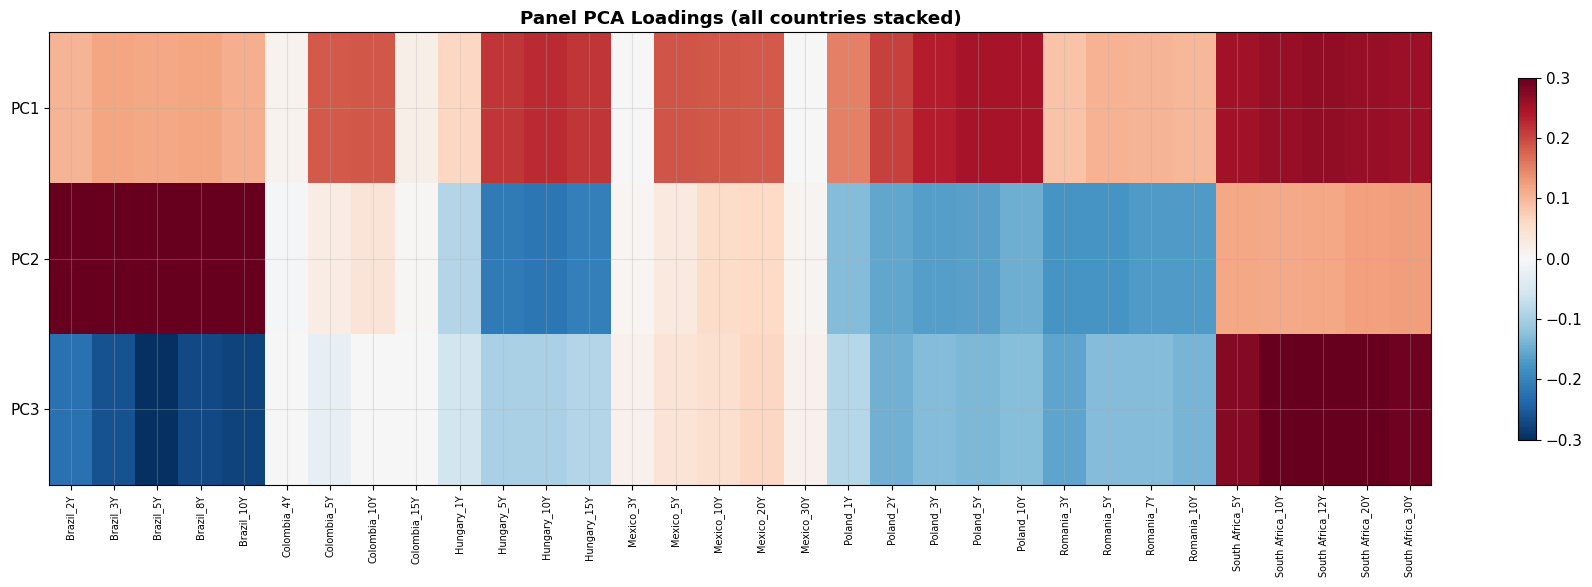

In [14]:
fig, ax = plt.subplots(figsize=(18, 6))
loadings_panel = pd.DataFrame(
    pca_panel.components_[:3].T,
    index=panel_dy.columns,
    columns=["PC1", "PC2", "PC3"],
)
im = ax.imshow(loadings_panel.T.values, aspect="auto", cmap="RdBu_r", vmin=-0.3, vmax=0.3)
ax.set_yticks(range(3))
ax.set_yticklabels(loadings_panel.columns)
ax.set_xticks(range(len(loadings_panel.index)))
ax.set_xticklabels(loadings_panel.index, rotation=90, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Panel PCA Loadings (all countries stacked)", fontweight="bold")
fig.tight_layout()
plt.savefig("data/output/pca_panel_loadings.png", dpi=150, bbox_inches="tight")
plt.show()


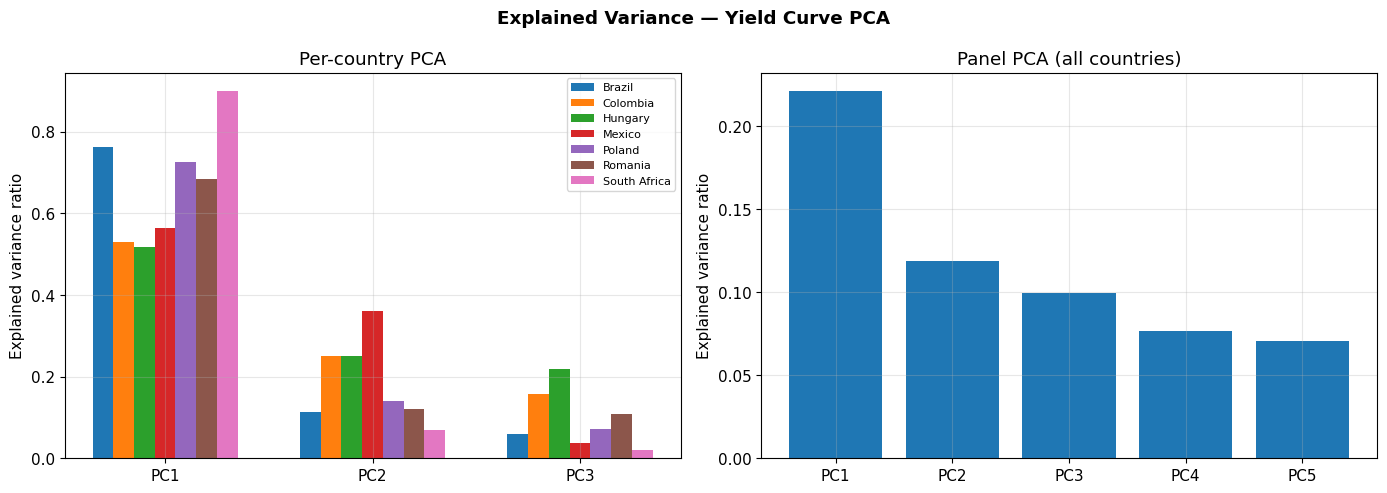

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
# Left: per-country
countries_sorted = sorted(pca_results.keys())
x = np.arange(3)
width = 0.1
for i, country in enumerate(countries_sorted):
    evr_c = pca_results[country]["pca"].explained_variance_ratio_
    ax1.bar(x + i * width, evr_c, width, label=country)
ax1.set_xticks(x + width * 3)
ax1.set_xticklabels(["PC1", "PC2", "PC3"])
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("Per-country PCA")
ax1.legend(fontsize=8)
 
# Right: panel
ax2.bar(range(5), pca_panel.explained_variance_ratio_, color="#1f77b4")
ax2.set_xticks(range(5))
ax2.set_xticklabels([f"PC{k+1}" for k in range(5)])
ax2.set_ylabel("Explained variance ratio")
ax2.set_title("Panel PCA (all countries)")
 
fig.suptitle("Explained Variance — Yield Curve PCA", fontweight="bold")
fig.tight_layout()
plt.savefig("data/output/pca_explained_variance.png", dpi=150, bbox_inches="tight")
plt.show()


### 1.3 Regime Detection via Clustering

k=2  BIC=9221
k=3  BIC=8811
k=4  BIC=8770
k=5  BIC=8781
k=6  BIC=8844

Best k by BIC: 4


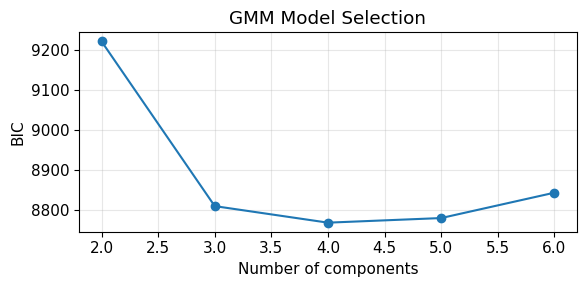

In [16]:

# Features: per-country PC1 scores + realized vol
features = regime_features[["avg_level", "dispersion", "real_vol"]].copy()
scaler_regime = StandardScaler()
features_std = scaler_regime.fit_transform(features)

# BIC to choose k
bics = {}
for k in range(2, 7):
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                           n_init=10, random_state=42)
    gmm.fit(features_std)
    bics[k] = gmm.bic(features_std)
    print(f"k={k}  BIC={bics[k]:.0f}")

best_k = min(bics, key=bics.get)
print(f"\nBest k by BIC: {best_k}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(list(bics.keys()), list(bics.values()), "-o")
ax.set_xlabel("Number of components")
ax.set_ylabel("BIC")
ax.set_title("GMM Model Selection")
fig.tight_layout()
plt.show()

In [17]:
gmm_final = GaussianMixture(n_components=best_k, covariance_type="full",
                              n_init=10, random_state=42)
regime_features["regime"] = gmm_final.fit_predict(features_std)
regime_features["regime_proba"] = gmm_final.predict_proba(features_std).max(axis=1)

# Centroids in original scale for interpretation
centroids = pd.DataFrame(
    scaler_regime.inverse_transform(gmm_final.means_),
    columns=["avg_level", "dispersion", "real_vol"],
)
centroids.index.name = "regime"
print("Cluster centroids (original scale):\n")
print(centroids.round(3))
print(f"\nCluster sizes:\n{regime_features['regime'].value_counts().sort_index()}")

Cluster centroids (original scale):

        avg_level  dispersion  real_vol
regime                                 
0           0.007       1.262     0.743
1          -1.216       3.909     1.277
2           0.164       2.123     1.289
3          -0.068       0.757     0.452

Cluster sizes:
regime
0    505
1     24
2    204
3    594
Name: count, dtype: int64


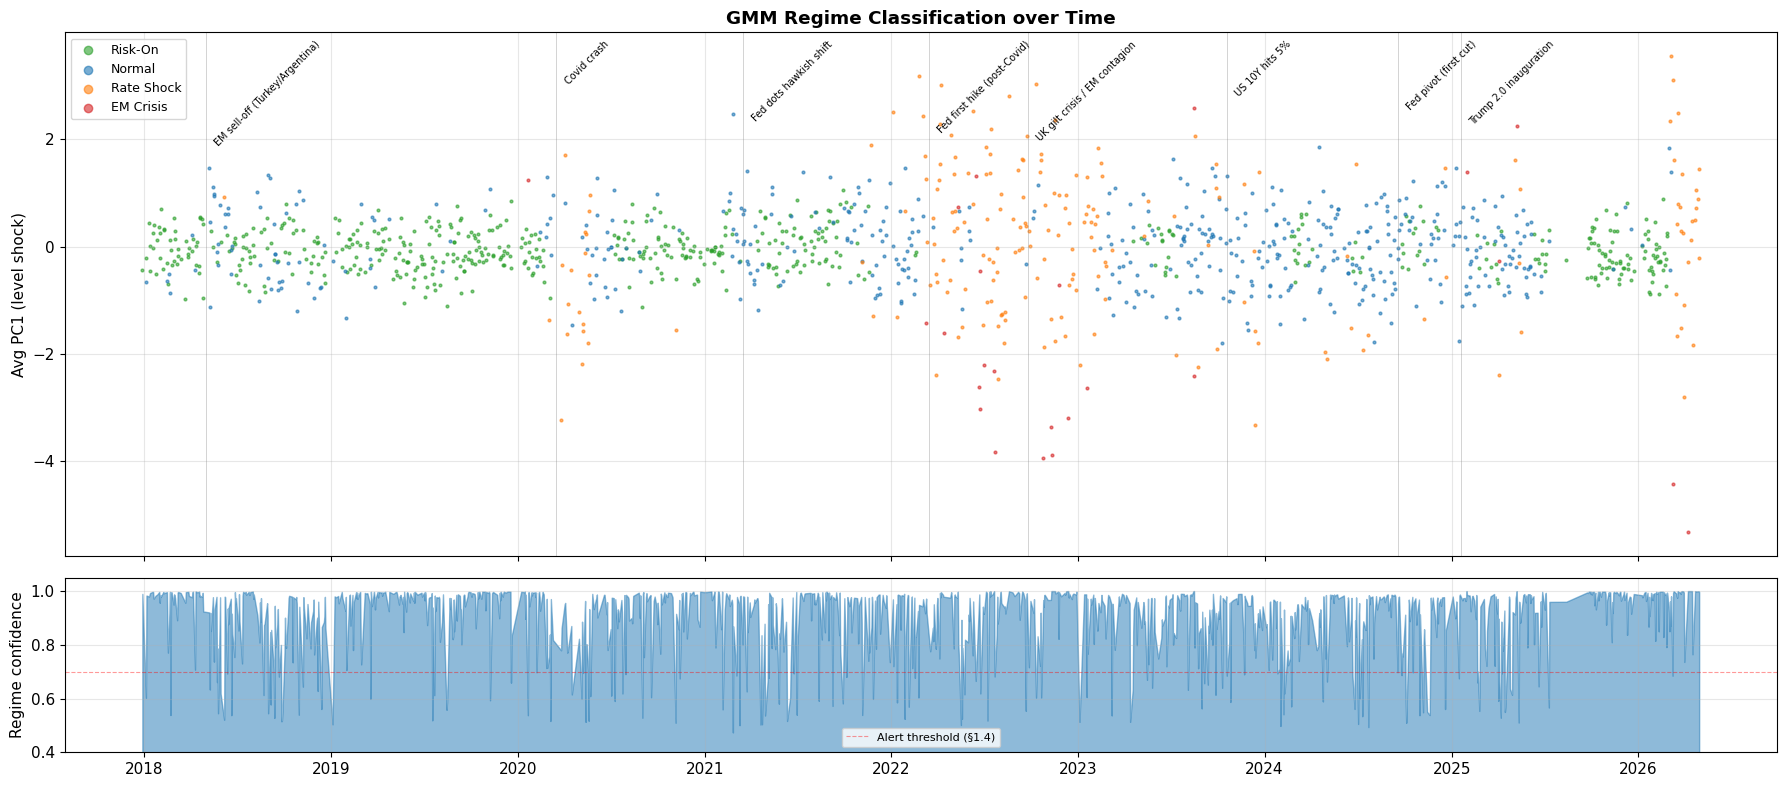

In [18]:
regime_labels = {
    0: "Normal",
    1: "EM Crisis",
    2: "Rate Shock",
    3: "Risk-On",
}

regime_colors = {
    "Risk-On": "#2ca02c",
    "Normal": "#1f77b4",
    "Rate Shock": "#ff7f0e",
    "EM Crisis": "#d62728",
}

regime_features["regime_label"] = regime_features["regime"].map(regime_labels)

fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True,
                          gridspec_kw={"height_ratios": [3, 1]})

# Top: avg_level with regime coloring
ax = axes[0]
for label in ["Risk-On", "Normal", "Rate Shock", "EM Crisis"]:
    mask = regime_features["regime_label"] == label
    ax.scatter(regime_features.index[mask], regime_features["avg_level"][mask],
               s=4, label=label, color=regime_colors[label], alpha=0.6)

for date_str, event in MACRO_EVENTS.items():
    evt = pd.Timestamp(date_str)
    if regime_features.index.min() <= evt <= regime_features.index.max():
        ax.axvline(evt, color="grey", alpha=0.4, linewidth=0.6)
        ax.annotate(event, xy=(evt, ax.get_ylim()[1]), xytext=(5, -5),
                    textcoords="offset points", fontsize=7, rotation=45, va="top")

ax.set_ylabel("Avg PC1 (level shock)")
ax.set_title("GMM Regime Classification over Time", fontweight="bold")
ax.legend(markerscale=3, fontsize=9)

# Bottom: regime probability (confidence)
axes[1].fill_between(regime_features.index, regime_features["regime_proba"],
                      alpha=0.5, color="#1f77b4")
axes[1].set_ylabel("Regime confidence")
axes[1].set_ylim(0.4, 1.05)
axes[1].axhline(0.7, color="red", linestyle="--", alpha=0.4, linewidth=0.8,
                label="Alert threshold (§1.4)")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.savefig("data/output/regime_classification.png", dpi=150, bbox_inches="tight")
plt.show()

### 1.4 Automated Alert Engine

In [19]:
def generate_alerts(date, regime_features, pca_results, change_dfs, MACRO_EVENTS):
    """Generate structured alerts for a single trading day."""
    alerts = []
    
    if date not in regime_features.index:
        return None
    
    row = regime_features.loc[date]
    
    # 1. Regime transition
    loc = regime_features.index.get_loc(date)
    if loc > 0:
        prev = regime_features.iloc[loc - 1]
        if row["regime"] != prev["regime"]:
            alerts.append({
                "type": "regime_shift",
                "severity": "high",
                "detail": f"Regime changed from {prev['regime_label']} to {row['regime_label']} "
                          f"(confidence: {row['regime_proba']:.0%})",
            })
    
    # 2. PC score z-score > 3 on any component (per country)
    for country, res in pca_results.items():
        scores = res["scores"]
        if date not in scores.index:
            continue
        for col in scores.columns:
            val = scores.loc[date, col]
            if abs(val) > 3.0:
                direction = "spike" if val > 0 else "drop"
                alerts.append({
                    "type": "pc_zscore_breach",
                    "severity": "medium" if abs(val) < 4 else "high",
                    "detail": f"{country} {col} z-score = {val:.2f} ({direction})",
                    "country": country,
                })
    
    # 3. Realized vol crosses 90th percentile (trailing 1Y = 252 days)
    vol_series = regime_features["real_vol"]
    vol_loc = vol_series.index.get_loc(date)
    if vol_loc >= 252:
        trailing_window = vol_series.iloc[vol_loc - 252 : vol_loc]
        p90 = trailing_window.quantile(0.9)
        if row["real_vol"] > p90:
            alerts.append({
                "type": "vol_spike",
                "severity": "medium",
                "detail": f"Realized vol ({row['real_vol']:.3f}) exceeds 90th percentile "
                          f"of trailing 1Y ({p90:.3f})",
            })
    
    # 4. Single-country curve move > 3 std from 60-day rolling mean
    for country, dy in change_dfs.items():
        if date not in dy.index:
            continue
        loc_c = dy.index.get_loc(date)
        if loc_c < 60:
            continue
        window = dy.iloc[loc_c - 60 : loc_c]
        today = dy.loc[date]
        rolling_mean = window.mean()
        rolling_std = window.std()
        for mat in dy.columns:
            if rolling_std[mat] == 0:
                continue
            z = (today[mat] - rolling_mean[mat]) / rolling_std[mat]
            if abs(z) > 3.0:
                alerts.append({
                    "type": "country_curve_outlier",
                    "severity": "low" if abs(z) < 4 else "medium",
                    "detail": f"{country} {mat} move = {today[mat]:+.2f} bps "
                              f"(z={z:.1f} vs 60d rolling)",
                    "country": country,
                })
    
    # Summary
    severity_order = {"high": 3, "medium": 2, "low": 1}
    alerts.sort(key=lambda a: severity_order.get(a["severity"], 0), reverse=True)
    max_severity = alerts[0]["severity"] if alerts else "none"
    
    return {
        "date": str(date.date()),
        "regime": row["regime_label"],
        "regime_confidence": round(row["regime_proba"], 3),
        "n_alerts": len(alerts),
        "max_severity": max_severity,
        "alerts": alerts,
    }

In [20]:
# Generate alerts for all dates
all_alerts = {}
for date in regime_features.index:
    result = generate_alerts(date, regime_features, pca_results, change_dfs, MACRO_EVENTS)
    if result and result["n_alerts"] > 0:
        all_alerts[str(date.date())] = result

print(f"Total days with at least one alert: {len(all_alerts)} / {len(regime_features)}")
print(f"Days with HIGH severity: {sum(1 for a in all_alerts.values() if a['max_severity'] == 'high')}")

# Show alerts for known stress dates
showcase_dates = ["2020-03-16", "2022-03-16", "2022-09-26", "2025-01-20"]
for d in showcase_dates:
    if d in all_alerts:
        print(f"\n{'='*60}")
        print(json.dumps(all_alerts[d], indent=2))
    else:
        target = pd.Timestamp(d)
        nearby = [k for k in all_alerts if abs(pd.Timestamp(k) - target).days <= 3]
        if nearby:
            nearest = min(nearby, key=lambda k: abs(pd.Timestamp(k) - target))
            print(f"\n{'='*60}")
            print(f"(No alerts on {d}, showing nearest: {nearest})")
            print(json.dumps(all_alerts[nearest], indent=2))
        else:
            print(f"\n{d}: no alerts within ±3 days")

# Save full alert history for Module 4
with open("data/output/alert_history.json", "w") as f:
    json.dump(all_alerts, f, indent=2)
print(f"\nSaved alert history to data/output/alert_history.json")

Total days with at least one alert: 762 / 1327
Days with HIGH severity: 488

2020-03-16: no alerts within ±3 days

(No alerts on 2022-03-16, showing nearest: 2022-03-18)
{
  "date": "2022-03-18",
  "regime": "Rate Shock",
  "regime_confidence": 0.776,
  "n_alerts": 3,
  "max_severity": "medium",
  "alerts": [
    {
      "type": "pc_zscore_breach",
      "severity": "medium",
      "detail": "Romania PC1 (level) z-score = -3.95 (drop)",
      "country": "Romania"
    },
    {
      "type": "vol_spike",
      "severity": "medium",
      "detail": "Realized vol (1.128) exceeds 90th percentile of trailing 1Y (0.888)"
    },
    {
      "type": "country_curve_outlier",
      "severity": "medium",
      "detail": "Romania 10Y move = -0.29 bps (z=-4.3 vs 60d rolling)",
      "country": "Romania"
    }
  ]
}

(No alerts on 2022-09-26, showing nearest: 2022-09-23)
{
  "date": "2022-09-23",
  "regime": "Rate Shock",
  "regime_confidence": 0.992,
  "n_alerts": 2,
  "max_severity": "high",
  "ale

## 2. Multi-method VaR Engine

In [21]:
# §2.1 — LC Fund Proxy P&L via duration approximation
# Weights from Company LC fund top exposures (rescaled to sum to 1)
lc_weights_raw = {
    "Brazil": 10.1, "Mexico": 8.8, "South Africa": 7.8, "Poland": 6.6
}
total = sum(lc_weights_raw.values())
lc_weights = {k: v / total for k, v in lc_weights_raw.items()}
print("Normalized LC weights:")
for k, v in lc_weights.items():
    print(f"  {k}: {v:.1%}")

# Duration from Bloomberg: LC fund effective duration = 5.22
D_eff = 5.22

# For each country, use the benchmark maturity closest to the fund duration
# (5Y for all four countries, which they all have)
benchmark_mat = "5Y"

# Build daily yield change series for the benchmark maturity per country
proxy_dy = pd.DataFrame({
    country: change_dfs[country][benchmark_mat]
    for country in lc_weights
})
proxy_dy = proxy_dy.dropna()

# Weighted portfolio yield change (in percentage points)
w_vec = np.array([lc_weights[c] for c in proxy_dy.columns])
portfolio_dy = proxy_dy @ w_vec  # weighted daily yield change

# Duration approximation: ΔP/P ≈ -D_eff × Δy (yield in decimal)
# Yield data is in percentage points, so divide by 100
portfolio_pnl = -D_eff * (portfolio_dy / 100)

print(f"\nPortfolio P&L series: {len(portfolio_pnl)} obs")
print(f"Mean daily return: {portfolio_pnl.mean():.4%}")
print(f"Daily vol: {portfolio_pnl.std():.4%}")
print(f"Annualized vol: {portfolio_pnl.std() * np.sqrt(252):.2%}")

Normalized LC weights:
  Brazil: 30.3%
  Mexico: 26.4%
  South Africa: 23.4%
  Poland: 19.8%

Portfolio P&L series: 1627 obs
Mean daily return: 0.0204%
Daily vol: 0.3692%
Annualized vol: 5.86%


In [22]:
# §2.2C — Historical Simulation VaR
# Multiple windows to match Bloomberg PORT VR options
windows = {"1Y": 252, "2Y": 504, "3Y": 756}

hist_var_results = {}
for label, w_len in windows.items():
    sample = portfolio_pnl.iloc[-w_len:]
    q_95 = np.quantile(sample, 0.05)
    q_99 = np.quantile(sample, 0.01)
    hist_var_results[f"Historical {label}"] = {
        "VaR_95": -q_95,
        "VaR_99": -q_99,
        "CVaR_95": -sample[sample <= q_95].mean(),
        "CVaR_99": -sample[sample <= q_99].mean(),
    }
    print(f"Historical {label} (n={len(sample)}): "
          f"VaR95={-q_95:.4%}  VaR99={-q_99:.4%}  "
          f"CVaR95={-sample[sample <= q_95].mean():.4%}")

Historical 1Y (n=252): VaR95=0.5305%  VaR99=1.0565%  CVaR95=0.7967%
Historical 2Y (n=504): VaR95=0.5036%  VaR99=0.8695%  CVaR95=0.7051%
Historical 3Y (n=756): VaR95=0.5267%  VaR99=0.8177%  CVaR95=0.7400%


In [23]:
# §2.2A — Parametric (Variance-Covariance) VaR
# Rolling 1Y covariance, matching Bloomberg default
mu = portfolio_pnl.mean()
sigma = portfolio_pnl.std()

# Normal
VaR_95_param_n = -(mu + norm.ppf(0.05) * sigma)
VaR_99_param_n = -(mu + norm.ppf(0.01) * sigma)
CVaR_95_param_n = -(mu - sigma * norm.pdf(norm.ppf(0.05)) / 0.05)
CVaR_99_param_n = -(mu - sigma * norm.pdf(norm.ppf(0.01)) / 0.01)

# Student-t (fit degrees of freedom from the data)
nu_fit, loc_fit, scale_fit = t_dist.fit(portfolio_pnl)
print(f"Fitted Student-t: nu={nu_fit:.1f}, loc={loc_fit:.6f}, scale={scale_fit:.6f}")

VaR_95_param_t = -(t_dist.ppf(0.05, df=nu_fit, loc=loc_fit, scale=scale_fit))
VaR_99_param_t = -(t_dist.ppf(0.01, df=nu_fit, loc=loc_fit, scale=scale_fit))
CVaR_95_param_t = -portfolio_pnl[portfolio_pnl <= -VaR_95_param_t].mean()
CVaR_99_param_t = -portfolio_pnl[portfolio_pnl <= -VaR_99_param_t].mean()

print(f"\nParametric (normal):  VaR95={VaR_95_param_n:.4%}  VaR99={VaR_99_param_n:.4%}")
print(f"Parametric (t, v={nu_fit:.0f}):  VaR95={VaR_95_param_t:.4%}  VaR99={VaR_99_param_t:.4%}")

Fitted Student-t: nu=2.0, loc=0.000168, scale=0.002164

Parametric (normal):  VaR95=0.5868%  VaR99=0.8384%
Parametric (t, v=2):  VaR95=0.6054%  VaR99=1.4450%


In [24]:
# §2.2B — Monte Carlo VaR
np.random.seed(42)
n_sims = 10_000

# A. Multivariate normal on the 4-country yield changes
mu_vec = proxy_dy.mean().values
cov_mat = proxy_dy.cov().values

sim_dy_normal = np.random.multivariate_normal(mu_vec, cov_mat, size=n_sims)
sim_pnl_normal = -D_eff * (sim_dy_normal @ w_vec) / 100

VaR_95_mc_n = -np.percentile(sim_pnl_normal, 5)
VaR_99_mc_n = -np.percentile(sim_pnl_normal, 1)
CVaR_95_mc_n = -sim_pnl_normal[sim_pnl_normal <= np.percentile(sim_pnl_normal, 5)].mean()
CVaR_99_mc_n = -sim_pnl_normal[sim_pnl_normal <= np.percentile(sim_pnl_normal, 1)].mean()

# B. Student-t copula (fatter tails, captures tail dependence)

# Fit marginal t-distributions per country
marginal_params = {}
for i, col in enumerate(proxy_dy.columns):
    nu, loc, scale = t_dist.fit(proxy_dy[col].dropna())
    marginal_params[col] = (nu, loc, scale)

# Transform to uniform via marginal CDFs, then to standard normal
U = np.zeros_like(proxy_dy.values, dtype=float)
for i, col in enumerate(proxy_dy.columns):
    nu, loc, scale = marginal_params[col]
    U[:, i] = t_dist.cdf(proxy_dy[col].values, df=nu, loc=loc, scale=scale)

# Clip to avoid inf in ppf
U = np.clip(U, 1e-6, 1 - 1e-6)
Z = norm.ppf(U)
corr_matrix = np.corrcoef(Z.T)

# Simulate from the copula
nu_copula = 5  # moderate fat tails
chi2_samples = np.random.chisquare(nu_copula, size=n_sims)
W = nu_copula / chi2_samples  # mixing variable

Z_sim = np.random.multivariate_normal(np.zeros(4), corr_matrix, size=n_sims)
T_sim = np.sqrt(W[:, None]) * Z_sim  # t-copula samples in standard normal space

# Transform back to original marginals via inverse CDF
sim_dy_copula = np.zeros_like(T_sim)
for i, col in enumerate(proxy_dy.columns):
    nu_m, loc_m, scale_m = marginal_params[col]
    u_sim = t_dist.cdf(T_sim[:, i], df=nu_copula)
    sim_dy_copula[:, i] = t_dist.ppf(u_sim, df=nu_m, loc=loc_m, scale=scale_m)

sim_pnl_copula = -D_eff * (sim_dy_copula @ w_vec) / 100

VaR_95_mc_t = -np.percentile(sim_pnl_copula, 5)
VaR_99_mc_t = -np.percentile(sim_pnl_copula, 1)
CVaR_95_mc_t = -sim_pnl_copula[sim_pnl_copula <= np.percentile(sim_pnl_copula, 5)].mean()
CVaR_99_mc_t = -sim_pnl_copula[sim_pnl_copula <= np.percentile(sim_pnl_copula, 1)].mean()

print(f"Monte Carlo (normal):     VaR95={VaR_95_mc_n:.4%}  VaR99={VaR_99_mc_n:.4%}")
print(f"Monte Carlo (t-copula):   VaR95={VaR_95_mc_t:.4%}  VaR99={VaR_99_mc_t:.4%}")

Monte Carlo (normal):     VaR95=0.5904%  VaR99=0.8267%
Monte Carlo (t-copula):   VaR95=0.5238%  VaR99=0.9943%


In [25]:
summary = pd.DataFrame({
    "Parametric (normal)": [VaR_95_param_n, VaR_99_param_n, CVaR_95_param_n, CVaR_99_param_n],
    "Parametric (t)": [VaR_95_param_t, VaR_99_param_t, CVaR_95_param_t, CVaR_99_param_t],
    "MC (normal)": [VaR_95_mc_n, VaR_99_mc_n, CVaR_95_mc_n, CVaR_99_mc_n],
    "MC (t-copula)": [VaR_95_mc_t, VaR_99_mc_t, CVaR_95_mc_t, CVaR_99_mc_t],
    "Historical 1Y": [hist_var_results["Historical 1Y"]["VaR_95"],
                       hist_var_results["Historical 1Y"]["VaR_99"],
                       hist_var_results["Historical 1Y"]["CVaR_95"],
                       hist_var_results["Historical 1Y"]["CVaR_99"]],
    "Historical 3Y": [hist_var_results["Historical 3Y"]["VaR_95"],
                       hist_var_results["Historical 3Y"]["VaR_99"],
                       hist_var_results["Historical 3Y"]["CVaR_95"],
                       hist_var_results["Historical 3Y"]["CVaR_99"]],
}, index=["VaR 95%", "VaR 99%", "CVaR 95%", "CVaR 99%"])

summary.map(lambda x: f"{x:.2%}")

,Parametric (normal),Parametric (t),MC (normal),MC (t-copula),Historical 1Y,Historical 3Y
VaR 95%,0.59%,0.61%,0.59%,0.52%,0.53%,0.53%
VaR 99%,0.84%,1.45%,0.83%,0.99%,1.06%,0.82%
CVaR 95%,0.74%,0.85%,0.74%,0.87%,0.80%,0.74%
CVaR 99%,0.96%,3.19%,0.95%,1.61%,1.27%,1.02%


In [26]:
def kupiec_pof(returns, VaR, p, alpha=0.05):
    T = len(returns)
    violations = (returns < -VaR)
    N = violations.sum()
    p_hat = N / T
    
    if N == 0:
        LR = -2 * T * np.log(1 - p)
    elif N == T:
        LR = -2 * T * np.log(p)
    else:
        LR = -2 * (
            N * np.log(p) + (T - N) * np.log(1 - p)
            - N * np.log(p_hat) - (T - N) * np.log(1 - p_hat)
        )
    
    p_value = 1 - chi2.cdf(LR, df=1)
    crit = chi2.ppf(1 - alpha, df=1)
    reject = LR > crit
    
    return {"T": T, "N": N, "expected": p * T, "violation_rate": p_hat,
            "LR": LR, "p_value": p_value, "reject_H0": reject}


def christoffersen_test(returns, VaR, alpha=0.05):
    """Independence test: are VaR breaches clustered?"""
    violations = (returns < -VaR).astype(int).values
    T = len(violations)
    
    # Transition counts
    n00 = n01 = n10 = n11 = 0
    for i in range(1, T):
        if violations[i-1] == 0 and violations[i] == 0: n00 += 1
        elif violations[i-1] == 0 and violations[i] == 1: n01 += 1
        elif violations[i-1] == 1 and violations[i] == 0: n10 += 1
        elif violations[i-1] == 1 and violations[i] == 1: n11 += 1
    
    # Avoid division by zero
    if n00 + n01 == 0 or n10 + n11 == 0 or n01 + n11 == 0:
        return {"LR_ind": np.nan, "p_value": np.nan, "reject_independence": False}
    
    p01 = n01 / (n00 + n01)
    p11 = n11 / (n10 + n11)
    p_hat = (n01 + n11) / (T - 1)
    
    # Log-likelihood under independence vs Markov
    L_ind = (n00 + n10) * np.log(1 - p_hat) + (n01 + n11) * np.log(p_hat)
    L_markov = n00 * np.log(1 - p01) + n01 * np.log(p01)
    if n10 > 0: L_markov += n10 * np.log(1 - p11)
    if n11 > 0: L_markov += n11 * np.log(p11)
    
    LR_ind = -2 * (L_ind - L_markov)
    p_value = 1 - chi2.cdf(LR_ind, df=1)
    
    return {"LR_ind": LR_ind, "p_value": p_value, "reject_independence": p_value < alpha}


# Models to backtest
backtest_models = {
    "Parametric (normal)": VaR_95_param_n,
    "Parametric (t)": VaR_95_param_t,
    "MC (normal)": VaR_95_mc_n,
    "MC (t-copula)": VaR_95_mc_t,
    "Historical 1Y": hist_var_results["Historical 1Y"]["VaR_95"],
    "Historical 3Y": hist_var_results["Historical 3Y"]["VaR_95"],
}

rows = []
for name, var_val in backtest_models.items():
    kup = kupiec_pof(portfolio_pnl, var_val, p=0.05)
    chris = christoffersen_test(portfolio_pnl, var_val)
    rows.append({
        "Model": name,
        "VaR 95%": f"{var_val:.4%}",
        "Violations": kup["N"],
        "Expected": f"{kup['expected']:.0f}",
        "Violation Rate": f"{kup['violation_rate']:.2%}",
        "Kupiec p": f"{kup['p_value']:.4f}",
        "Kupiec OK": "Pass" if not kup["reject_H0"] else "FAIL",
        "Christ. p": f"{chris['p_value']:.4f}" if not np.isnan(chris['p_value']) else "N/A",
        "Indep. OK": "Pass" if not chris["reject_independence"] else "FAIL",
    })

bt_df = pd.DataFrame(rows).set_index("Model")
bt_df

,VaR 95%,Violations,Expected,Violation Rate,Kupiec p,Kupiec OK,Christ. p,Indep. OK
Model,,,,,,,,
Parametric (normal),0.5868%,68,81,4.18%,0.1185,Pass,0.0851,Pass
Parametric (t),0.6054%,66,81,4.06%,0.0714,Pass,0.1829,Pass
MC (normal),0.5904%,68,81,4.18%,0.1185,Pass,0.0851,Pass
MC (t-copula),0.5238%,84,81,5.16%,0.7642,Pass,0.2120,Pass
Historical 1Y,0.5305%,84,81,5.16%,0.7642,Pass,0.2120,Pass
Historical 3Y,0.5267%,84,81,5.16%,0.7642,Pass,0.2120,Pass


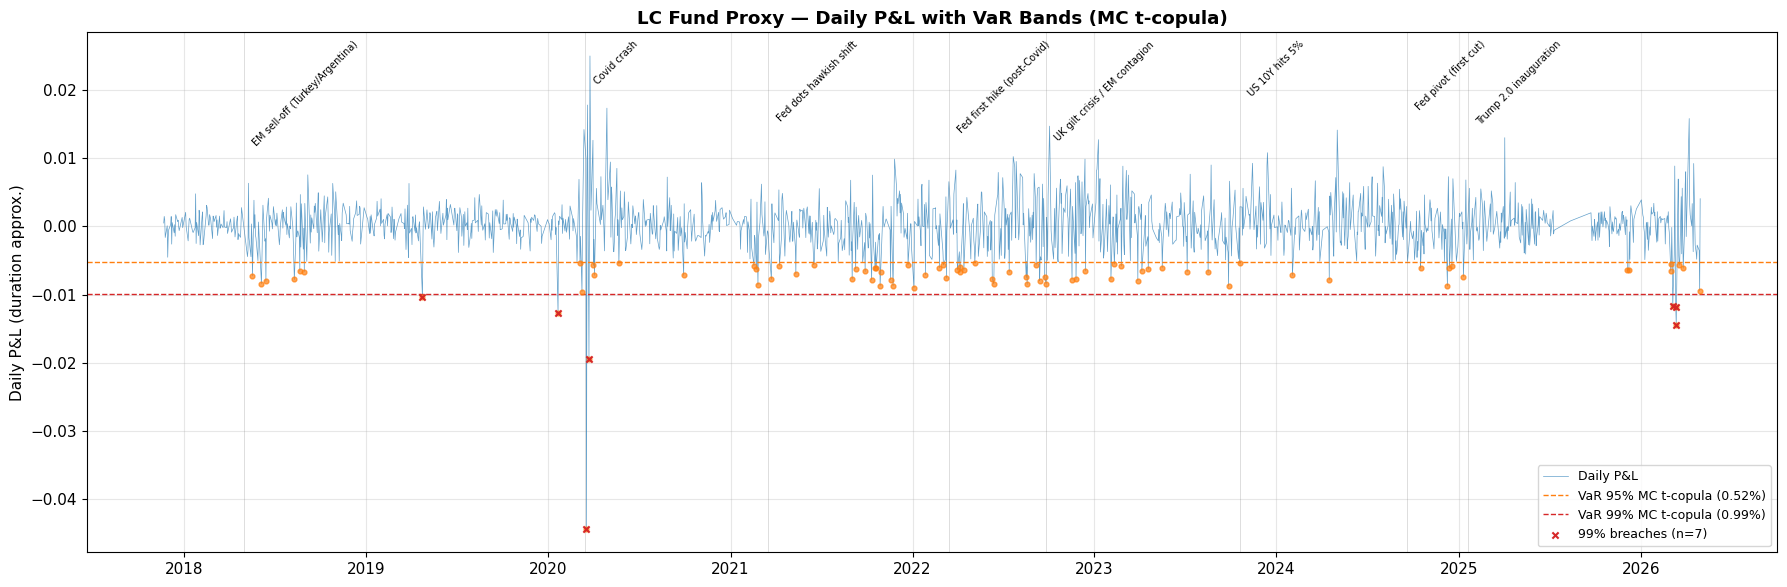

In [27]:
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(portfolio_pnl.index, portfolio_pnl.values, linewidth=0.5, color="#1f77b4", alpha=0.7,
        label="Daily P&L")

# VaR bands (using MC t-copula as the primary model)
ax.axhline(-VaR_95_mc_t, color="#ff7f0e", linestyle="--", linewidth=1, label=f"VaR 95% MC t-copula ({VaR_95_mc_t:.2%})")
ax.axhline(-VaR_99_mc_t, color="#d62728", linestyle="--", linewidth=1, label=f"VaR 99% MC t-copula ({VaR_99_mc_t:.2%})")

# Mark breaches
breaches_95 = portfolio_pnl[portfolio_pnl < -VaR_95_mc_t]
breaches_99 = portfolio_pnl[portfolio_pnl < -VaR_99_mc_t]
ax.scatter(breaches_95.index, breaches_95.values, color="#ff7f0e", s=12, zorder=5, alpha=0.7)
ax.scatter(breaches_99.index, breaches_99.values, color="#d62728", s=20, zorder=6, marker="x",
           label=f"99% breaches (n={len(breaches_99)})")

for date_str, event in MACRO_EVENTS.items():
    evt = pd.Timestamp(date_str)
    if portfolio_pnl.index.min() <= evt <= portfolio_pnl.index.max():
        ax.axvline(evt, color="grey", alpha=0.3, linewidth=0.6)
        ax.annotate(event, xy=(evt, ax.get_ylim()[1]), xytext=(5, -5),
                    textcoords="offset points", fontsize=7, rotation=45, va="top")

ax.set_ylabel("Daily P&L (duration approx.)")
ax.set_title("LC Fund Proxy — Daily P&L with VaR Bands (MC t-copula)", fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.savefig("data/output/var_pnl_bands.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Daily Briefing Engine

In [28]:
def build_daily_payload(date, regime_features, pca_results, change_dfs,
                        portfolio_pnl, all_alerts, VaR_95_mc_t, VaR_99_mc_t):
    """Pack all analytics for a single date into a structured dict for the LLM."""
    date = pd.Timestamp(date)
    payload = {"date": str(date.date())}
    
    # Regime
    if date in regime_features.index:
        row = regime_features.loc[date]
        payload["regime"] = {
            "label": row["regime_label"],
            "confidence": round(row["regime_proba"], 3),
            "avg_level_shock": round(row["avg_level"], 3),
            "dispersion": round(row["dispersion"], 3),
            "realized_vol": round(row["real_vol"], 3),
        }
    
    # Per-country curve moves
    curve_moves = {}
    for country, dy in change_dfs.items():
        if date in dy.index:
            moves = dy.loc[date].to_dict()
            curve_moves[country] = {mat: round(v, 3) for mat, v in moves.items()
                                     if not np.isnan(v)}
    payload["curve_moves_bps"] = curve_moves
    
    # Per-country PCA scores
    pc_scores = {}
    for country, res in pca_results.items():
        if date in res["scores"].index:
            scores = res["scores"].loc[date]
            pc_scores[country] = {
                "PC1_level": round(scores.iloc[0], 2),
                "PC2_slope": round(scores.iloc[1], 2),
                "PC3_curvature": round(scores.iloc[2], 2),
            }
    payload["pc_scores"] = pc_scores
    
    # Portfolio P&L
    if date in portfolio_pnl.index:
        pnl = portfolio_pnl.loc[date]
        payload["portfolio"] = {
            "daily_pnl_pct": round(pnl * 100, 4),
            "var_95_mc_tcopula": round(VaR_95_mc_t * 100, 4),
            "var_99_mc_tcopula": round(VaR_99_mc_t * 100, 4),
            "var_breach_95": pnl < -VaR_95_mc_t,
            "var_breach_99": pnl < -VaR_99_mc_t,
        }
    
    # Alerts
    date_str = str(date.date())
    if date_str in all_alerts:
        payload["alerts"] = all_alerts[date_str]["alerts"]
    else:
        payload["alerts"] = []
    
    return payload


# Test on a known stress date
test_payload = build_daily_payload("2022-09-23", regime_features, pca_results,
                                    change_dfs, portfolio_pnl, all_alerts,
                                    VaR_95_mc_t, VaR_99_mc_t)
print(json.dumps(test_payload, indent=2, default=str))

{
  "date": "2022-09-23",
  "regime": {
    "label": "Rate Shock",
    "confidence": 0.992,
    "avg_level_shock": 2.063,
    "dispersion": 2.248,
    "realized_vol": 1.282
  },
  "curve_moves_bps": {
    "Brazil": {
      "2Y": 0.05,
      "3Y": 0.07,
      "5Y": 0.13,
      "8Y": 0.12,
      "10Y": 0.13
    },
    "Colombia": {
      "4Y": 0.045,
      "5Y": 0.023,
      "10Y": 0.136,
      "15Y": 0.07
    },
    "Hungary": {
      "1Y": -0.14,
      "5Y": -0.24,
      "10Y": -0.03,
      "15Y": 0.01
    },
    "Mexico": {
      "3Y": 0.065,
      "5Y": 0.06,
      "10Y": 0.105,
      "20Y": 0.12,
      "30Y": 0.115
    },
    "Poland": {
      "1Y": 0.002,
      "2Y": 0.068,
      "3Y": 0.15,
      "5Y": 0.202,
      "10Y": 0.267
    },
    "Romania": {
      "3Y": 0.06,
      "5Y": 0.06,
      "7Y": 0.09,
      "10Y": 0.18
    },
    "South Africa": {
      "5Y": 0.205,
      "10Y": 0.18,
      "12Y": 0.24,
      "20Y": 0.28,
      "30Y": 0.265
    }
  },
  "pc_scores": {
    "Braz

In [29]:
with open("private/gemini_key.txt") as f:
    api_key = f.read().strip()

client = genai.Client(api_key=api_key)

SYSTEM_PROMPT = """You are a Fixed Income analyst at an EM debt asset manager.
You produce daily morning briefings for the portfolio manager of an EM local-currency sovereign bond fund.

Given structured daily analytics data (regime classification, yield curve moves, PCA scores, VaR metrics, and alerts), produce a briefing with:

1. **Headline** (one sentence, max 15 words): the single most important thing today.
2. **Regime context** (1-2 sentences): current regime, confidence, what it implies.
3. **Notable country moves** (2-3 sentences): which countries moved, direction, magnitude in bps, and any PCA z-score flags.
4. **Risk update** (1-2 sentences): portfolio P&L, proximity to VaR bands, any breaches.
5. **Alerts** (if any): list triggered alerts with severity.

Rules:
- Be precise and quantitative. No filler.
- Use basis points for yield moves.
- Flag anything that warrants PM attention with [ACTION NEEDED] prefix.
- Total length: 8-12 sentences maximum.
- If no alerts fired, say "No alerts triggered."
"""

def generate_briefing(date, regime_features, pca_results, change_dfs,
                      portfolio_pnl, all_alerts, VaR_95_mc_t, VaR_99_mc_t):
    """Generate an LLM daily briefing for a given date."""
    payload = build_daily_payload(date, regime_features, pca_results, change_dfs,
                                  portfolio_pnl, all_alerts, VaR_95_mc_t, VaR_99_mc_t)
    
    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=f"{SYSTEM_PROMPT}\n\nGenerate the daily briefing for this data:\n\n"
                 f"{json.dumps(payload, indent=2, default=str)}"
    )
    
    return payload["date"], response.text

In [30]:
showcase_dates = [
    "2022-03-18",
    "2022-09-23",
    "2023-06-15",
    "2024-09-18",
    "2025-01-22",
]

CACHE_PATH = "data/output/sample_briefings.json"

# Load existing cache
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH) as f:
        briefings = json.load(f)
    print(f"Loaded {len(briefings)} cached briefings")
else:
    briefings = {}

# Only generate missing dates
for d in showcase_dates:
    target = str(pd.Timestamp(d).date())
    if target in briefings:
        print(f"\n{target}: cached (skipping API call)")
        continue
    try:
        date_out, text = generate_briefing(d, regime_features, pca_results, change_dfs,
                                            portfolio_pnl, all_alerts, VaR_95_mc_t, VaR_99_mc_t)
        briefings[date_out] = text
        print(f"\n{target}: generated via API")
        time.sleep(5)
    except Exception as e:
        print(f"\n{target}: failed — {e}")

# Save updated cache
with open(CACHE_PATH, "w") as f:
    json.dump(briefings, f, indent=2)

# Display all
for date_out, text in briefings.items():
    print(f"\n{'='*70}")
    print(f"DAILY BRIEFING — {date_out}")
    print(f"{'='*70}")
    print(text)

Loaded 0 cached briefings

2022-03-18: generated via API

2022-09-23: generated via API

2023-06-15: generated via API

2024-09-18: generated via API

2025-01-22: generated via API

DAILY BRIEFING — 2022-03-18
**Morning Briefing: 2022-03-18**

**Headline:** Romania sees extreme yield plunge amidst Rate Shock and volatility spike.

We are currently in a "Rate Shock" regime with 77.6% confidence, implying significant and sudden rate movements, accompanied by elevated realized volatility of 1.128.

Romania experienced an extreme yield drop, with its 10Y falling 29 bps, flagged by a PC1 (level) z-score of -3.95 and a curve outlier alert. Mexico also saw a significant level drop, with 10Y yields down 15 bps and a PC1 z-score of -2.02. Brazil's curve steepened notably (PC2 z-score of -2.96), with its 2Y down 35.5 bps and 10Y up 6.5 bps, while South Africa's 10Y yields rose 7 bps (PC1 z-score of 1.88).

The portfolio recorded a daily P&L of -0.0254%. No VaR breaches occurred against the 95% (